In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().absolute().parent))


import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.data_models.caravanify import Caravanify, CaravanifyConfig

# Step 1: Extract Anthropogenic Attributes

A good source for anthropogenic attributes is the following link: https://data.hydrosheds.org/file/technical-documentation/BasinATLAS_Catalog_v10.pdf   


In [3]:
# config = CaravanifyConfig(
#     attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/attributes",
#     timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/timeseries/csv",
#     shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CA/post_processed/shapefiles",
#     gauge_id_prefix="CA",
#     use_hydroatlas_attributes=True,
#     use_caravan_attributes=True,
#     use_other_attributes=True,
# )
# # Load the static attributes for all gauges

# caravan = Caravanify(config)
# ids_for_training = caravan.get_all_gauge_ids()[:100]
# caravan.load_stations(ids_for_training)
# static_data = caravan.get_static_attributes()

# # Identify anthropogenic attributes in the dataset
# anthro_columns = [
#     "ppd_pk_sav",  # Population density
#     "urb_pc_sse",  # Urban extent
#     "rdd_mk_sav",  # Road density
#     "nli_ix_sav",  # Nighttime lights
#     "gdp_ud_sav",  # GDP
#     "hdi_ix_sav",  # Human development index
#     "dor_pc_pva",  #  Degree or regulation
#     "rev_mc_usu",  # Reservoir volume
# ]

# # Check which attributes are actually present in the dataset
# available_anthro = [col for col in anthro_columns if col in static_data.columns]
# print(f"Available anthropogenic attributes: {available_anthro}")

# # Create subset with only anthropogenic attributes and gauge_id
# anthro_data = static_data[["gauge_id"] + available_anthro].copy()
# print("\nAnthropogenic attributes data:")
# print(anthro_data.head())

# Step 2: Handle Missing Values

In [4]:
# # Check for missing values
# missing_values = anthro_data.isna().sum()
# print("Missing values per attribute:")
# print(missing_values)

# # Impute missing values with median
# for col in available_anthro:
#    if anthro_data[col].isna().any():
#        median_val = anthro_data[col].median()
#        anthro_data[col].fillna(median_val, inplace=True)

# print("\nAfter imputation - missing values:")
# print(anthro_data.isna().sum())

# Step 3: Normalize Attributes


In [5]:
# # Initialize the scaler
# scaler = MinMaxScaler()

# # Fit and transform the data (excluding gauge_id)
# norm_data = pd.DataFrame(
#    scaler.fit_transform(anthro_data[available_anthro]),
#    columns=available_anthro
# )

# # Add gauge_id back to normalized data
# norm_data['gauge_id'] = anthro_data['gauge_id'].values

# print("Normalized anthropogenic attributes:")
# print(norm_data.head())

# Step 4: Define weights and calculate Human Influence Index (HII)


In [6]:
# # weights = {attr: 1/len(available_anthro) for attr in available_anthro}
# # print("Weights assigned to each attribute:")
# # print(weights)

# # anthro_columns = [
# #     "ppd_pk_sav",  # Population density
# #     "urb_pc_sse",  # Urban extent
# #     "rdd_mk_sav",  # Road density
# #     "nli_ix_sav",  # Nighttime lights
# #     "gdp_ud_sav",  # GDP
# #     "hdi_ix_sav",  # Human development index
# #     "dor_pc_pva",  #  Degree or regulation
# #     "rev_mc_usu",  # Reservoir volume
# # ]

# weights_raw = {'ppd_pk_sav':1, 'urb_pc_sse':1, 'rdd_mk_sav':1, 'nli_ix_sav':1, 'gdp_ud_sav':3, 'hdi_ix_sav':1, 'dor_pc_pva':5, 'rev_mc_usu':5}

# weights = {attr: 1/len(available_anthro) for attr in available_anthro}
# for attr in available_anthro:
#     if attr in weights_raw:
#         weights[attr] = weights_raw[attr] / sum(weights_raw.values())
#     else:
#         weights[attr] = 0


# assert sum(weights.values()) == 1, "Weights should sum up to 1"

# print("Weights assigned to each attribute:")
# print(weights)



In [7]:
# available_anthro

In [8]:
# # Calculate HII (weighted sum of normalized attributes)
# hii_values = np.zeros(len(norm_data))

# for attr in available_anthro:
#    hii_values += weights[attr] * norm_data[attr].values

# # Add HII to the normalized data
# norm_data['hii'] = hii_values / np.max(hii_values)

# print("\nData with HII scores:")
# print(norm_data[['gauge_id', 'hii']].head())

# Step 5: Categorize catchments based on HII


In [9]:
# # Define thresholds for categories (using tertiles)
# low_threshold = 0.3
# high_threshold = 0.5

# # Assign categories
# def assign_category(hii):
#    if hii < low_threshold:
#        return "Low"
#    elif hii < high_threshold:
#        return "Medium"
#    else:
#        return "High"

# norm_data['human_influence_category'] = norm_data['hii'].apply(assign_category)

# # Count catchments in each category
# category_counts = norm_data['human_influence_category'].value_counts()
# print("\nCount of catchments in each category:")
# print(category_counts)

# # Add original attributes to the output
# result_df = pd.merge(
#    norm_data[['gauge_id', 'hii', 'human_influence_category']],
#    anthro_data,
#    on='gauge_id'
# )

# print("\nFinal classification with original values:")
# print(result_df.head())

# basin_count = len(ids_for_training)
# number_of_bins = int(np.ceil(2 * basin_count ** (1/3)))


# plt.figure(figsize=(10, 6))
# plt.hist(norm_data['hii'], bins=20, color='skyblue', edgecolor='black')
# plt.axvline(low_threshold, color='green', linestyle='--', label=f'Low threshold: {low_threshold:.3f}')
# plt.axvline(high_threshold, color='red', linestyle='--', label=f'High threshold: {high_threshold:.3f}')
# plt.xlabel('Human Influence Index (HII)')
# plt.ylabel('Frequency')
# plt.title('Distribution of Human Influence Index')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()

# Step 6: Plot streamflow data for examples from each category


In [10]:
# # Get one example from each category
# example_gauges = {}
# for category in ["Low", "Medium", "High"]:
#     # Randomly select a gauge_id for each category
#     category_gauges = result_df[result_df["human_influence_category"] == category][
#         "gauge_id"
#     ].values
#     if len(category_gauges) > 0:
#         example_gauges[category] = np.random.choice(category_gauges)
#     else:
#         print(f"No catchments in {category} category")

# # Plot streamflow time series for each example
# plt.figure(figsize=(10, 6))

# all_ts_data = caravan.get_time_series()

# for category, gauge_id in example_gauges.items():
#     ts_data = all_ts_data[all_ts_data["gauge_id"] == gauge_id]

#     # Keep only data from 2000 to 2001
#     ts_data = ts_data[
#         (ts_data["date"] >= "2010-01-01") & (ts_data["date"] <= "2010-12-31")
#     ]

#     if len(ts_data) > 0 and "streamflow" in ts_data.columns:
#         # Convert date to datetime if needed
#         if not pd.api.types.is_datetime64_any_dtype(ts_data["date"]):
#             ts_data["date"] = pd.to_datetime(ts_data["date"])

#         # Plot streamflow
#         plt.plot(
#             ts_data["date"],
#             ts_data["streamflow"],
#             label=f"{gauge_id} ({category} human influence)",
#             alpha=0.8,
#         )
#     else:
#         print(f"No streamflow data available for {gauge_id}")

# plt.xlabel("Date")
# plt.ylabel("Streamflow (mm/day)")
# plt.title("Streamflow Comparison by Human Influence Category")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# sns.despine()
# plt.show()

# # Create a table with human influence metrics for the examples
# comparison_df = result_df[result_df["gauge_id"].isin(example_gauges.values())]
# print("\nComparison of human influence metrics:")
# display(
#     comparison_df[["gauge_id", "human_influence_category", "hii"] + available_anthro]
# )

In [11]:
# # Find basin CH_2239
# basin_id = "CH_2239"
# if basin_id in result_df["gauge_id"].values:
#     basin_data = result_df[result_df["gauge_id"] == basin_id]
#     print(f"\nData for basin {basin_id}:")
#     display(basin_data)
# else:
#     print(f"Basin {basin_id} not found in the dataset.")

# # Plot streamflow time series for basin CH_2239
# plt.figure(figsize=(10, 6))
# ts_data = all_ts_data[all_ts_data["gauge_id"] == basin_id]
# ts_data = ts_data[
#     (ts_data["date"] >= "2000-01-01") & (ts_data["date"] <= "2003-12-31")
# ]
# if len(ts_data) > 0 and "streamflow" in ts_data.columns:
#     if not pd.api.types.is_datetime64_any_dtype(ts_data["date"]):
#         ts_data["date"] = pd.to_datetime(ts_data["date"])

#     plt.plot(
#         ts_data["date"],
#         ts_data["streamflow"],
#         label=f"{basin_id}",
#         alpha=0.8,
#     )
# else:
#     print(f"No streamflow data available for {basin_id}")
# plt.xlabel("Date")
# plt.ylabel("Streamflow (mm/day)")
# plt.title(f"Streamflow for Basin {basin_id}")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# sns.despine()
# plt.show()

---
# Checking the results

In [15]:
config = CaravanifyConfig(
    attributes_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/attributes",
    timeseries_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/timeseries/csv",
    shapefile_dir="/Users/cooper/Desktop/CAMELS-CH/data/CARAVANIFY/CH/post_processed/shapefiles",
    gauge_id_prefix="CH",
    use_hydroatlas_attributes=True,
    use_caravan_attributes=True,
    use_other_attributes=True,
)
# Load the static attributes for all gauges

caravan = Caravanify(config)

ids_for_training = caravan.get_all_gauge_ids()

gdf = caravan.get_shapefiles()
gdf = gdf[gdf["gauge_id"].isin(ids_for_training)]

gdf.head()

,gauge_id,geometry
2,CH_2009,"MULTIPOLYGON Z (((7.00197 46.37201 0, 7.00197 ..."
3,CH_2011,"POLYGON Z ((7.89701 46.41781 0, 7.89952 46.416..."
5,CH_2016,"POLYGON Z ((8.18842 47.48429 0, 8.18867 47.483..."
7,CH_2018,"POLYGON Z ((8.33544 47.42163 0, 8.33545 47.421..."
8,CH_2019,"POLYGON Z ((8.45045 46.76463 0, 8.44995 46.764..."


In [16]:
path_to_hii = "/Users/cooper/Desktop/CAMELS-CH/src/human_influence_index/results/human_influence_classification.csv"
hii_df = pd.read_csv(path_to_hii)
hii_df = hii_df[hii_df["gauge_id"].isin(ids_for_training)]
hii_df.head()

,gauge_id,hii,human_influence_category
0,CH_2009,0.395035,High
1,CH_2011,0.358416,High
2,CH_2016,0.505520,High
3,CH_2018,0.570296,High
4,CH_2019,0.348128,High


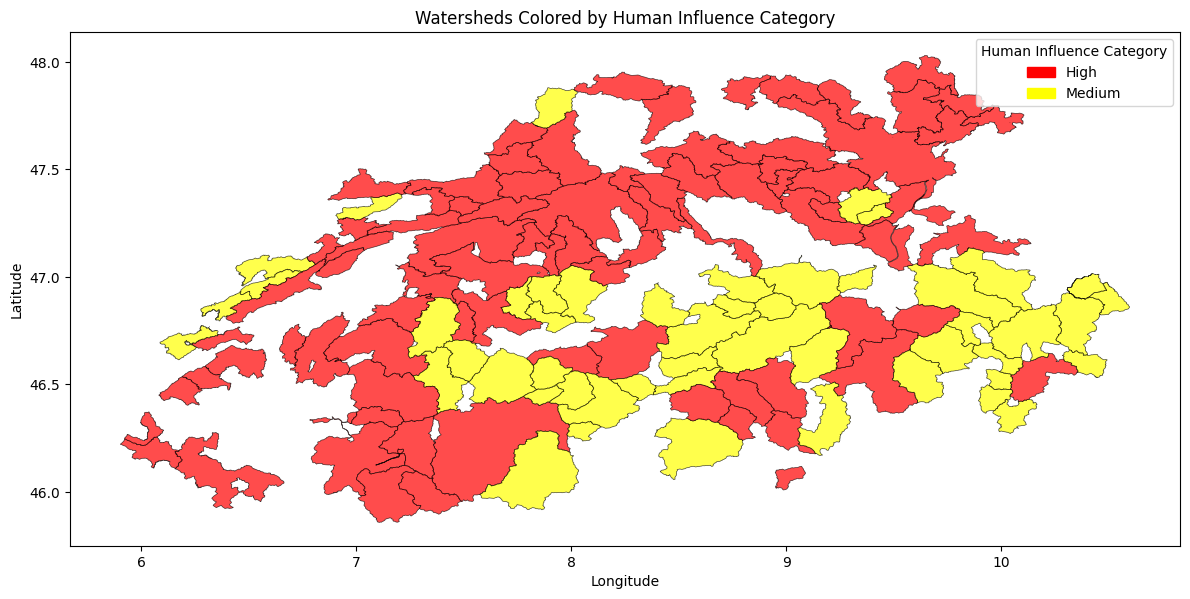

In [17]:
import matplotlib.patches as mpatches

# Create the GeoDataFrame and human influence DataFrame from your data
# Note: In your actual code, these are already loaded

# Merge the human influence data with the GeoDataFrame
merged_gdf = gdf.merge(hii_df, on="gauge_id", how="left")

# Define the color mapping
color_map = {"High": "red", "Medium": "yellow", "Low": "green"}

# Create a column for colors
merged_gdf["color"] = merged_gdf["human_influence_category"].apply(
    lambda x: color_map.get(x, "gray")
)

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the entire GeoDataFrame with colors
merged_gdf.plot(
    ax=ax, color=merged_gdf["color"], alpha=0.7, edgecolor="black", linewidth=0.5
)

# Create legend elements
legend_elements = [
    mpatches.Patch(color=color, label=category)
    for category, color in color_map.items()
    if category in merged_gdf["human_influence_category"].unique()
]

# Add the legend
ax.legend(handles=legend_elements, title="Human Influence Category", loc="best")

# Add title and configure plot
plt.title("Watersheds Colored by Human Influence Category")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
plt.tight_layout()

# Show the plot
plt.show()